In [1]:
dataset_type = "Test"
dataset_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Dataset/"+dataset_type

label_path = dataset_path+"/label.mm"
patch_path = dataset_path+"/patch.mm"

meta_data_path = dataset_path+"/meta.txt"

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt


def visualize_sample(label_path, org_patch_path, meta_data_path, n):

    # ---------- Load metadata ----------
    with open(meta_data_path, "r") as f:
        meta = json.load(f)

    # ---------- Load memmaps ----------
    labels = np.memmap(
        label_path,
        dtype=np.uint8,
        mode='r',
        shape=tuple(meta["focus_labels"]["shape"])
    )

    org_patches = np.memmap(
        org_patch_path,
        dtype=np.uint8,
        mode='r',
        shape=tuple(meta["patches"]["shape"])
    )

    # ---------- Get sample ----------
    
    if n == -1:
        n = np.random.randint(0, len(labels))
    
    label = int(labels[n])
    images = org_patches[n]   # (49, H, W)
    print("N = ",n)
    print("Label = ",label)
    # print(labels)

    # ---------- Plot ----------
    fig, axes = plt.subplots(7, 7, figsize=(10, 10))

    import matplotlib.patches as patches

    for i in range(49):
        ax = axes[i // 7, i % 7]
        ax.imshow(images[i], cmap='gray')
        ax.axis('off')

        if i == label:
            rect = patches.Rectangle(
                (0, 0),
                images[i].shape[1],
                images[i].shape[0],
                linewidth=5,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)

    plt.tight_layout()
    plt.show()

N =  5417
Label =  18


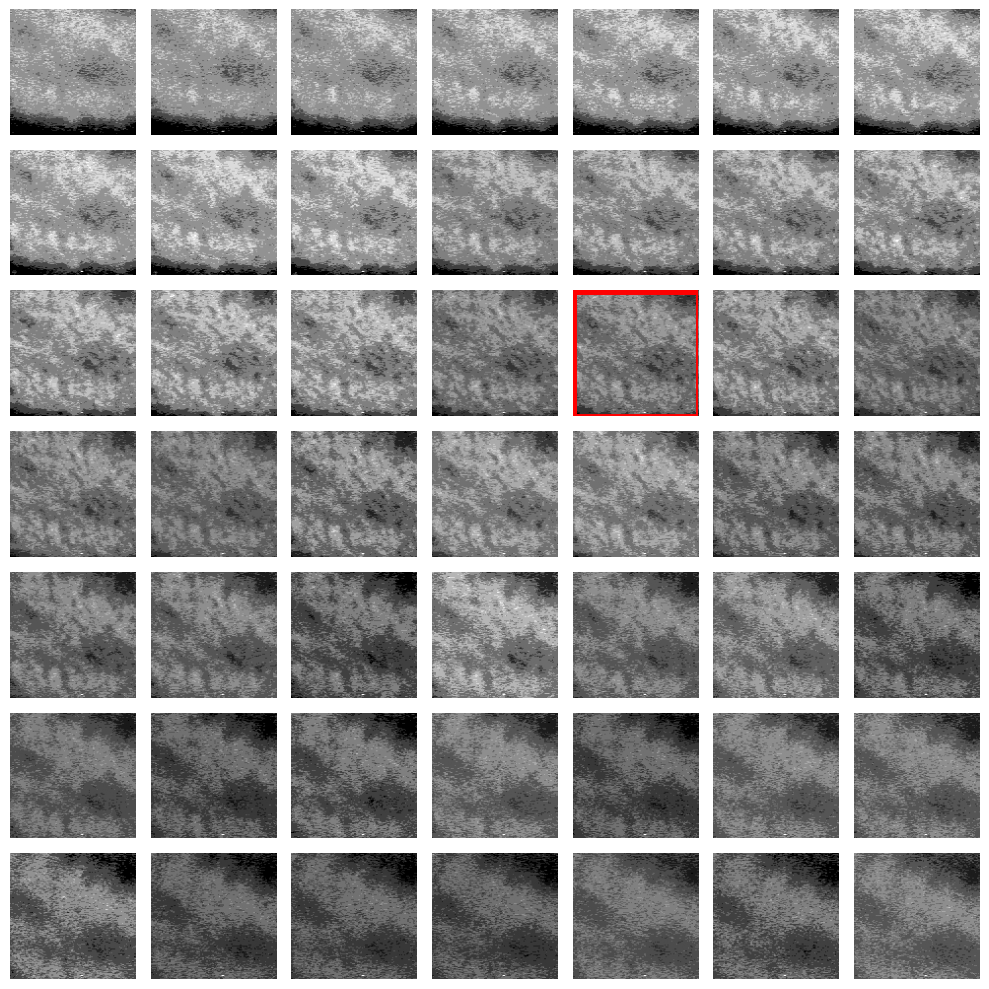

In [13]:
visualize_sample(label_path, patch_path, meta_data_path,n=-1)

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt


def plot_label_histogram(label_path, meta_data_path):

    # ---------- Load metadata ----------
    with open(meta_data_path, "r") as f:
        meta = json.load(f)

    # ---------- Load memmap ----------
    labels = np.memmap(
        label_path,
        dtype=np.uint8,
        mode='r',
        shape=tuple(meta["focus_labels"]["shape"])
    )

    labels = np.asarray(labels)  # convert to array for processing

    # ---------- Count occurrences ----------
    counts = np.bincount(labels, minlength=49)  # indices 0–48

    x = np.arange(1, 50)        # display as 1–49
    y = counts[:49]

    # ---------- Plot ----------
    plt.figure(figsize=(16, 4))
    plt.bar(x, y)
    plt.xlabel("Focus Label (1–49)")
    plt.ylabel("Count")
    plt.title("Label Distribution")
    plt.xticks(x)
    plt.show()

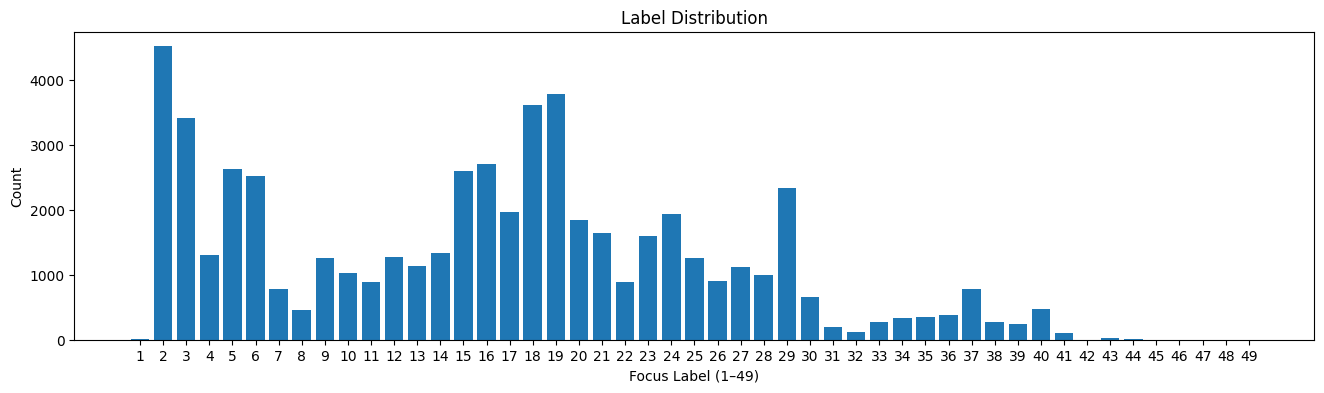

In [14]:
plot_label_histogram(label_path, meta_data_path)